**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Install Required Libraries**

In [ ]:
!pip install -q timm torchvision seaborn


**Imports**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Device Configuration

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


Image Transformations

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])


Load Dataset

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/data/train"
TEST_DIR  = "/content/drive/MyDrive/data/test"

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

class_names = train_ds.classes
print("Classes:", class_names)
print("Train size:", len(train_ds))
print("Test size:", len(test_ds))


Classes: ['Accident', 'Non Accident']
Train size: 791
Test size: 100


Load Swin-Tiny (Pretrained Transformer)

In [ ]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=2
)

model = model.to(device)
model


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

Freeze 90% of the Model

In [ ]:
for name, param in model.named_parameters():
    param.requires_grad = False

# Unfreeze classification head + last stage
for name, param in model.named_parameters():
    if "head" in name or "layers.3" in name:
        param.requires_grad = True


Loss Function & Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)


Training Model

In [ ]:
EPOCHS = 8

for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {correct/total:.4f}")


Epoch 1/8 | Loss: 0.6101 | Train Acc: 0.6890
Epoch 2/8 | Loss: 0.5064 | Train Acc: 0.7889
Epoch 3/8 | Loss: 0.4324 | Train Acc: 0.8609
Epoch 4/8 | Loss: 0.3927 | Train Acc: 0.8559
Epoch 5/8 | Loss: 0.3619 | Train Acc: 0.8900
Epoch 6/8 | Loss: 0.3378 | Train Acc: 0.9153
Epoch 7/8 | Loss: 0.3308 | Train Acc: 0.9166
Epoch 8/8 | Loss: 0.3188 | Train Acc: 0.9292


Evaluation

In [ ]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())


Classification Report

In [ ]:
print("\n Classification Report:\n")
print(classification_report(
    y_true, y_pred,
    target_names=class_names
))



 Classification Report:

              precision    recall  f1-score   support

    Accident       0.96      0.94      0.95        47
Non Accident       0.94      0.96      0.95        53

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



Confusion Matrix + Accuracy


 Overall Accuracy: 0.9500


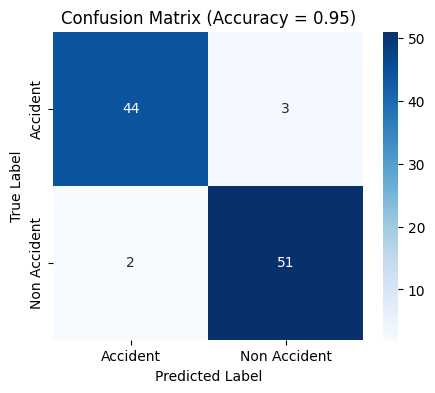

In [ ]:
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

print(f"\n Overall Accuracy: {acc:.4f}")

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix (Accuracy = {acc:.2f})")
plt.show()


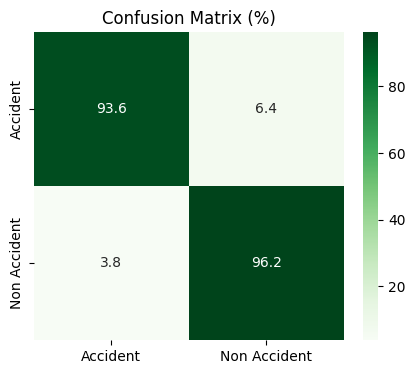

In [ ]:
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix (%)")
plt.show()


Save Model

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/swin_accident_detector.pth"
torch.save(model.state_dict(), MODEL_PATH)

print("Model saved at:", MODEL_PATH)


Model saved at: /content/drive/MyDrive/swin_accident_detector.pth


Show Predictions


In [ ]:
from IPython.display import display
from PIL import Image
import torch
import os

def show_console_predictions(model, dataset, class_names, limit=20):
    model.eval()
    print("\n Showing predictions in console...\n")

    for i in range(min(limit, len(dataset))):
        img, true_label = dataset[i]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_input)
            probs = torch.softmax(outputs, dim=1)[0]
            pred = torch.argmax(probs).item()

        predicted_class = class_names[pred]
        confidence = probs[pred].item()
        actual_class = class_names[true_label]

        print("===================================")
        print(f"Actual Label   : {actual_class}")
        print(f"Predicted Label: {predicted_class}")
        print(f"Confidence     : {confidence:.2f}")
        print("===================================")

        # Convert tensor to image
        img_np = img.permute(1,2,0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        display(Image.fromarray((img_np * 255).astype('uint8')))



 Showing predictions in console...

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 1.00


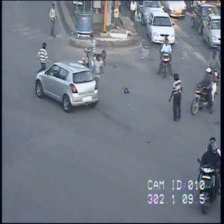

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.97


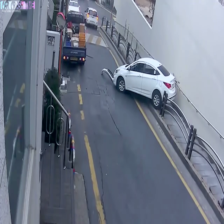

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.98


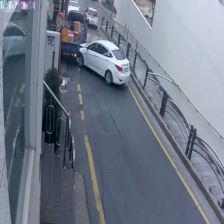

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.97


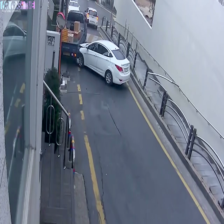

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.97


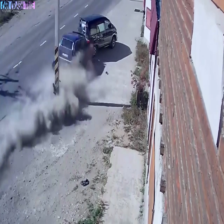

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.99


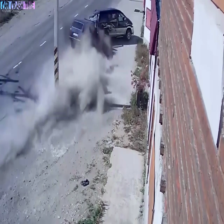

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.77


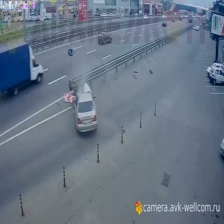

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.94


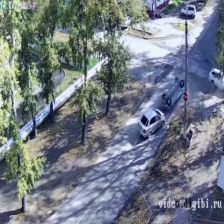

Actual Label   : Accident
Predicted Label: Non Accident
Confidence     : 0.64


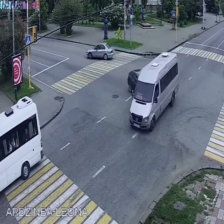

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.71


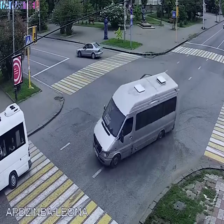

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.98


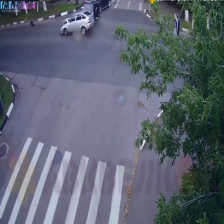

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.99


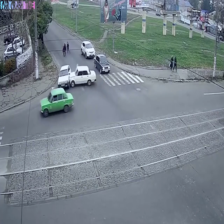

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.99


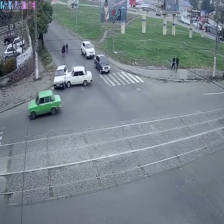

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.99


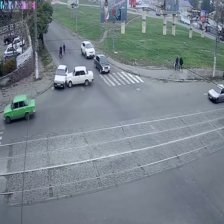

Actual Label   : Accident
Predicted Label: Accident
Confidence     : 0.98


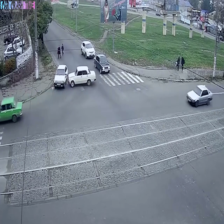

In [ ]:
show_console_predictions(model, test_ds, class_names, limit=15)


Grid View

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_prediction_grid(model, dataset, class_names, rows=5, cols=5):
    model.eval()
    total = rows * cols

    plt.figure(figsize=(20, 10))

    for i in range(total):
        img, _ = dataset[i]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_input)
            probs = torch.softmax(outputs, dim=1)[0]
            pred = torch.argmax(probs).item()

        label = class_names[pred]
        conf = probs[pred].item()

        # Convert tensor to numpy image
        img_np = img.permute(1,2,0).cpu().numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        img_np = (img_np * 255).astype(np.uint8)

        # Border color
        color = (255,0,0) if label == "Accident" else (0,255,0)
        img_np = cv2.copyMakeBorder(
            img_np, 6,6,6,6, cv2.BORDER_CONSTANT, value=color
        )

        plt.subplot(rows, cols, i+1)
        plt.imshow(img_np)
        plt.title(f"{label}\n{conf:.2f}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


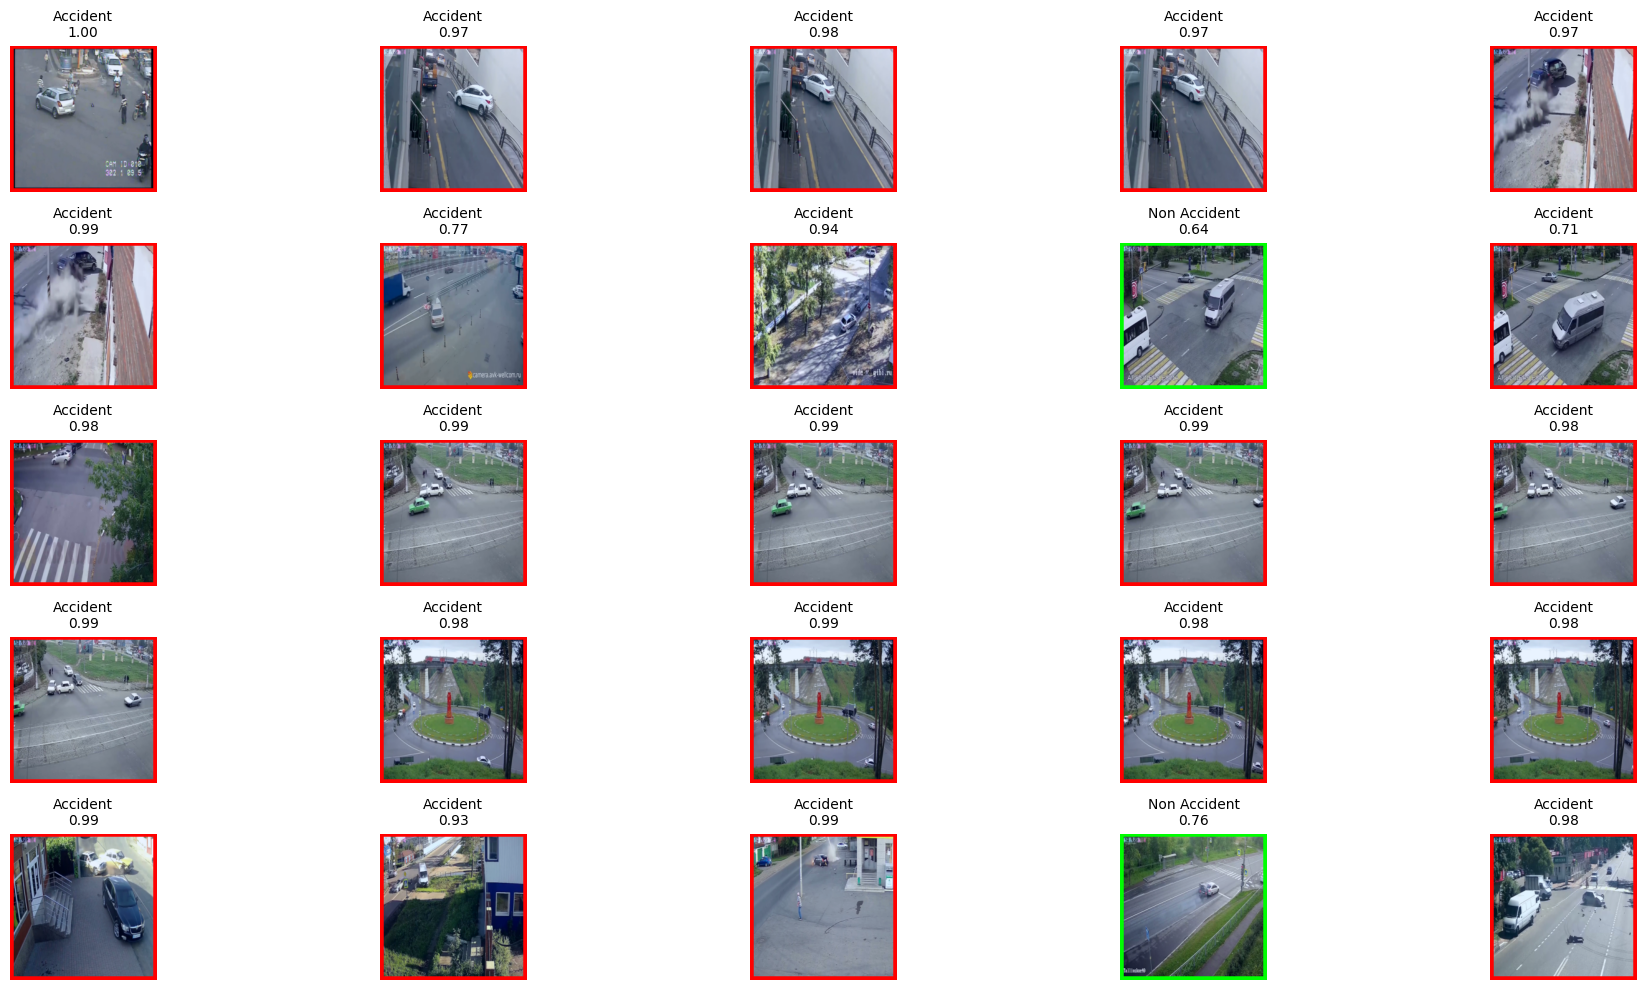

In [ ]:
show_prediction_grid(model, test_ds, class_names, rows=5, cols=5)
